
Benchmarking Signature Algorithm: ML-DSA-87 (NIST Level 5)
Running 100 iterations for benchmarking...


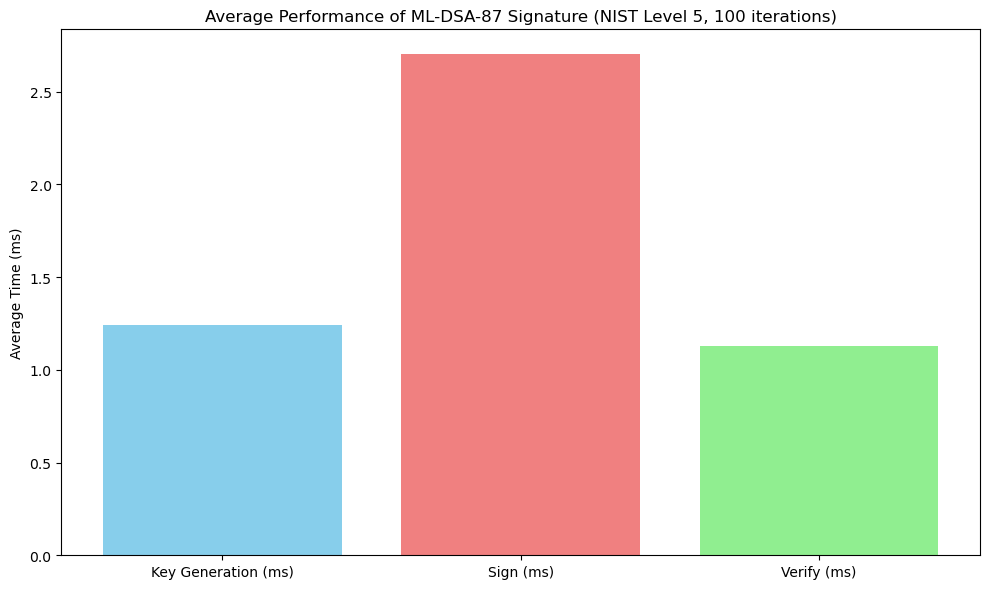


--- Benchmark Results ---
Algorithm: ML-DSA-87 (NIST Level 5)
Iterations: 100
Average Key Generation Time: 1.2408 ms
Average Sign Time:          2.7015 ms
Average Verify Time:        1.1272 ms

Overall verification success during benchmark: True


In [1]:
import logging
from pprint import pformat
from sys import stdout
import time  # Import the time module for benchmarking
import statistics  # Import statistics for calculating mean
import matplotlib.pyplot as plt # Import matplotlib

import oqs

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(stdout))

message = b"This is the message to sign" * 10  # Make message slightly longer

# Choose algorithm for NIST Level 5 (Comparable to AES-256)
# --- CHANGE HERE ---
sigalg = "ML-DSA-87"
# --- CHANGE ENDS ---
logger.info(f"\nBenchmarking Signature Algorithm: {sigalg} (NIST Level 5)")

# Number of iterations for benchmarking
N_ITERATIONS = 100  # You might adjust this based on performance
logger.info(f"Running {N_ITERATIONS} iterations for benchmarking...")

# Lists to store timings
keygen_times = []
sign_times = []
verify_times = []

# --- Benchmarking Loop ---
all_valid = True  # Flag to track if all verifications passed
for i in range(N_ITERATIONS):
    # Need fresh objects for each key generation benchmark iteration
    try:
        with oqs.Signature(sigalg) as signer, oqs.Signature(sigalg) as verifier:

            # 1. Benchmark Key Generation
            start_time = time.perf_counter()
            signer_public_key = signer.generate_keypair()
            end_time = time.perf_counter()
            keygen_times.append(end_time - start_time)
            # secret_key = signer.export_secret_key() # Need secret key if recreating signer later

            # 2. Benchmark Signing
            # Note: Signing uses the private key held internally by 'signer'
            start_time = time.perf_counter()
            signature = signer.sign(message)
            end_time = time.perf_counter()
            sign_times.append(end_time - start_time)

            # 3. Benchmark Verification
            start_time = time.perf_counter()
            is_valid = verifier.verify(message, signature, signer_public_key)
            end_time = time.perf_counter()
            verify_times.append(end_time - start_time)

            if not is_valid:
                logger.warning(f"Signature verification failed during iteration {i+1}!")
                all_valid = False
                # Decide if you want to break or continue benchmarking
                # break

    except oqs.MechanismNotEnabledError:
        logger.error(f"ERROR: The algorithm '{sigalg}' is not enabled in your liboqs build.")
        logger.error("Please check your liboqs installation and ensure it was built with support for this algorithm.")
        # Clear lists as benchmark couldn't complete
        keygen_times, sign_times, verify_times = [], [], []
        all_valid = False
        break  # Exit the loop

# Check if benchmarking actually ran
if not keygen_times:
    logger.error("Benchmarking could not be performed.")
else:
    # --- Calculate and Print Results ---
    avg_keygen_ms = statistics.mean(keygen_times) * 1000
    avg_sign_ms = statistics.mean(sign_times) * 1000
    avg_verify_ms = statistics.mean(verify_times) * 1000

    # --- Generate the Graph ---
    labels = ['Key Generation (ms)', 'Sign (ms)', 'Verify (ms)']
    times = [avg_keygen_ms, avg_sign_ms, avg_verify_ms]
    colors = ['skyblue', 'lightcoral', 'lightgreen']

    plt.figure(figsize=(10, 6))
    plt.bar(labels, times, color=colors)
    plt.ylabel("Average Time (ms)")
    plt.title(f"Average Performance of {sigalg} Signature (NIST Level 5, {N_ITERATIONS} iterations)")
    plt.xticks(labels)
    plt.tight_layout()
    plt.show()

    # --- Print Text Results ---
    logger.info("\n--- Benchmark Results ---")
    logger.info(f"Algorithm: {sigalg} (NIST Level 5)")
    logger.info(f"Iterations: {N_ITERATIONS}")
    logger.info(f"Average Key Generation Time: {avg_keygen_ms:.4f} ms")
    logger.info(f"Average Sign Time:          {avg_sign_ms:.4f} ms")
    logger.info(f"Average Verify Time:        {avg_verify_ms:.4f} ms")

    # --- Final Verification Check ---
    logger.info(f"\nOverall verification success during benchmark: {all_valid}")